In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV # Use timeseriessplit to avoid data leakage
from sklearn.linear_model import Lasso, lasso_path, LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, accuracy_score 
from xgboost import XGBRegressor
import yfinance
import requests


In [3]:
def load_btc_data(days):
    try:
        df = yfinance.download("BTC-USD", period=f"{days}d", interval="1d", progress=False)
        df.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in df.columns]
        df.index.name = "date"
        df = df[["open", "high", "low", "close", "volume"]]
        if len(df) > 0:
            print(f"Loaded {len(df)} rows from Yahoo Finance. Latest close: ${df['close'].iloc[-1]:,}")
            return df

    except Exception as e:
        print("Error", e)

In [4]:
def fetch_mvrv(start_date="2012-01-01"):
    url = "https://community-api.coinmetrics.io/v4/timeseries/asset-metrics"
    params = {
        "assets": "btc",
        "metrics": "CapMVRVCur",
        "start_time": start_date,
        "page_size": 10000,
        "frequency": "1d",
    }

    all_data = []
    while True:
        resp = requests.get(url, params=params)
        resp.raise_for_status()
        payload = resp.json()
        all_data.extend(payload["data"])
        next_url = payload.get("next_page_url")
        if not next_url:
            break
        url    = next_url
        params = {}

    df_mvrv = pd.DataFrame(all_data)
    df_mvrv["date"]      = pd.to_datetime(df_mvrv["time"]).dt.tz_localize(None).dt.normalize()
    df_mvrv["CapMVRVCur"] = pd.to_numeric(df_mvrv["CapMVRVCur"], errors="coerce")
    return df_mvrv[["date", "CapMVRVCur"]].set_index("date")


In [5]:
def add_features(df):
    d = df.copy()
    c = d["close"]

    # Returns
    d["returns_1d"]  = c.pct_change(1)
    d["returns_3d"]  = c.pct_change(3)
    d["returns_7d"]  = c.pct_change(7)
    d["log_returns"] = np.log(c / c.shift(1))

    # Moving averages & ratios
    for w in [7, 14, 21, 50]:
        d[f"sma_{w}"] = c.rolling(w).mean()
        d[f"ema_{w}"] = c.ewm(span=w, adjust=False).mean()

    d["price_sma7_ratio"]  = c / d["sma_7"]
    d["price_sma21_ratio"] = c / d["sma_21"]
    d["sma7_sma21_ratio"]  = d["sma_7"] / d["sma_21"]

    # Volatility
    d["volatility_7d"]  = d["log_returns"].rolling(7).std()
    d["volatility_14d"] = d["log_returns"].rolling(14).std()

    # Relative Strength Index
    delta = c.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    d["rsi_14"] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

    # Moving Average Convergence Divergence
    ema12            = c.ewm(span=12, adjust=False).mean()
    ema26            = c.ewm(span=26, adjust=False).mean()
    d["macd"]        = ema12 - ema26
    d["macd_signal"] = d["macd"].ewm(span=9, adjust=False).mean()
    d["macd_hist"]   = d["macd"] - d["macd_signal"]

    # Bollinger Bands
    roll20           = c.rolling(20)
    d["bb_mid"]      = roll20.mean()
    d["bb_upper"]    = d["bb_mid"] + 2 * roll20.std()
    d["bb_lower"]    = d["bb_mid"] - 2 * roll20.std()
    d["bb_width"]    = (d["bb_upper"] - d["bb_lower"]) / d["bb_mid"]
    d["bb_position"] = (c - d["bb_lower"]) / (d["bb_upper"] - d["bb_lower"])

    # Average true range
    high, low, prev_close = d["high"], d["low"], c.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    d["atr_14"]  = tr.rolling(14).mean()
    d["atr_pct"] = d["atr_14"] / c

    # Volume
    d["volume_sma7"]  = d["volume"].rolling(7).mean()
    d["volume_ratio"] = d["volume"] / d["volume_sma7"]

    # Candlestick shape
    d["candle_body"]  = (c - d["open"]) / d["open"]
    d["candle_range"] = (d["high"] - d["low"]) / d["open"]

    # Lags
    for lag in [1, 2, 3, 5, 7]:
        d[f"close_lag_{lag}"] = c.shift(lag)

    # Day of week effect
    d["dow"] = d.index.dayofweek

    # Direction lags
    d["direction_lag1"] = (c.pct_change(1) > 0).astype(int).shift(1)
    d["direction_lag2"] = (c.pct_change(1) > 0).astype(int).shift(2)

    return d.dropna()

In [6]:
features = [
    "returns_1d", "returns_3d", "returns_7d", "log_returns",
    "sma_7", "sma_14", "sma_21", "sma_50",
    "ema_7", "ema_14", "ema_21", "ema_50",
    "price_sma7_ratio", "price_sma21_ratio", "sma7_sma21_ratio",
    "volatility_7d", "volatility_14d",
    "rsi_14", "macd", "macd_signal", "macd_hist",
    "bb_width", "bb_position", "atr_pct",
    "volume_ratio", "candle_body", "candle_range",
    "close_lag_1", "close_lag_2", "close_lag_3", "close_lag_5", "close_lag_7",
    "dow",
    "direction_lag1", "direction_lag2",
    "mvrv", "mvrv_change", "mvrv_z"
]
lasso_features = [
    "returns_1d", "returns_3d", "returns_7d", "log_returns",
    "price_sma7_ratio", "price_sma21_ratio", "sma7_sma21_ratio",
    "volatility_7d", "volatility_14d",
    "rsi_14", "macd_hist",
    "bb_width", "bb_position", "atr_pct",
    "volume_ratio", "candle_body", "candle_range",
    "dow",
    "direction_lag1", "direction_lag2",
    "mvrv", "mvrv_change", "mvrv_z"
]


In [7]:
# Prepare X and y
days = 6200 # 6,280 days since Bitcoin was first mined
df_raw = load_btc_data(days)
df = add_features(df_raw)

mvrv_raw = fetch_mvrv()
df.index = pd.to_datetime(df.index).tz_localize(None).normalize()
df = df.join(mvrv_raw.rename(columns={"CapMVRVCur": "mvrv"}), how="left")

# Derived MVRV features
df["mvrv_change"] = df["mvrv"].pct_change(7)
df["mvrv_z"]      = (
    (df["mvrv"] - df["mvrv"].rolling(90).mean())
    / df["mvrv"].rolling(90).std()
)
df = df.dropna(subset=["mvrv", "mvrv_change", "mvrv_z"])
print(f"Rows after adding MVRV: {len(df)}")


# Target = cumulative % return over the next 3 days
df["target"] = df["close"].pct_change(3).shift(-3)
df = df.dropna(subset=["target"] + features)

threshold = 0.01
df_filtered = df[df["target"].abs() > threshold].copy()
print(f"\nRows before threshold filter : {len(df)}")
print(f"Rows after threshold filter : {len(df_filtered)} (threshold = ±{threshold:.0%})")

X = df_filtered[features].values
y = df_filtered["target"].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7, shuffle=False
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Standardize Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Loaded 4201 rows from Yahoo Finance. Latest close: $71,037.75
Rows after adding MVRV: 4062

Rows before threshold filter : 4059
Rows after threshold filter : 3178 (threshold = ±1%)
Training set size: 2542
Test set size: 636


Linear Regression

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)
lin_r2_train = lin_reg.score(X_train_scaled, y_train)
lin_r2_test = lin_reg.score(X_test_scaled,  y_test)
lin_dir_acc = accuracy_score((y_test > 0).astype(int), (y_pred_lin > 0).astype(int))

print("Linear Regression:")
print("Training R^2:", lin_r2_train)
print("Test R^2:", lin_r2_test)
print("Directional Accuracy:", lin_dir_acc)

Linear Regression (OLS):
Training R^2: 0.043327930942079096
Test R^2: -0.21365351021795087
Directional Accuracy: 0.5015723270440252


Logistic Regression

In [9]:
y_train_dir = (y_train > 0).astype(int)
y_test_dir = (y_test > 0).astype(int)

log_reg = LogisticRegression(max_iter=1000, random_state=7)
log_reg.fit(X_train_scaled, y_train_dir)

y_pred_log = log_reg.predict(X_test_scaled)
log_dir_acc = accuracy_score(y_test_dir, y_pred_log)
log_train_acc = log_reg.score(X_train_scaled, y_train_dir)

print("Logistic Regression:")
print("Training Accuracy:", log_train_acc)
print("Test Accuracy: ", log_dir_acc)


Logistic Regression:
Training Accuracy: 0.580251770259638
Test Accuracy:  0.4889937106918239


Lasso with CV lambda grid

In [ ]:
# Set subsets for train test sets
X_lasso_train = df_filtered[lasso_features].values[:len(X_train)]
X_lasso_test = df_filtered[lasso_features].values[len(X_train):]

lasso_scaler = StandardScaler()
X_lasso_train_scaled = lasso_scaler.fit_transform(X_lasso_train)
X_lasso_test_scaled = lasso_scaler.transform(X_lasso_test)

lambdas = np.logspace(-6, 1, 50)
tscv = TimeSeriesSplit(n_splits=5)

cv_mse = [
    np.mean([
        mean_squared_error(
            y_train[val],
            Lasso(alpha=l, max_iter=10000).fit(X_lasso_train_scaled[tr], y_train[tr]).predict(X_lasso_train_scaled[val])
        )
        for tr, val in tscv.split(X_lasso_train_scaled)
    ])
    for l in lambdas
]

cv_mse = np.array(cv_mse)
lambda_min = lambdas[np.argmin(cv_mse)]
lambda_1se = lambdas[cv_mse <= cv_mse.min() + cv_mse.std()][-1]

print("Lasso CV results:")
print("lambda_min =", lambda_min)
print("lambda_1se =", lambda_1se)

lasso_model = Lasso(alpha=lambda_min, max_iter=10000)
lasso_model.fit(X_lasso_train_scaled, y_train)
print(f"Non-zero coefficients at lambda_min: {np.sum(lasso_model.coef_ != 0)} / {len(lasso_features)}")

Lasso CV results:
lambda_min = 0.003727593720314938
lambda_1se = 10.0
Non-zero coefficients at lambda_min: 3 / 23


Random Forest

In [11]:

param_grid = {
    "max_depth": [2, 3, 5, 7],
    "min_samples_leaf": [10, 20, 30, 50],
    "max_features": ["sqrt", 0.3, 0.5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(n_estimators=200, random_state=7, oob_score=True),
    param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_mean_squared_error",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

print("Tuned Random Forest using TimeSeriesSplit:")
print("Best params:", grid_search.best_params_)
print("Training R^2:", best_rf.score(X_train, y_train))
print("Test R^2:", best_rf.score(X_test, y_test))
print("OOB Error:", (1 - grid_search.best_estimator_.oob_score_))

Tuned Random Forest using TimeSeriesSplit:
Best params: {'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 50}
Training R^2: 0.03720460357165656
Test R^2: -0.00702808119199716
OOB Error: 0.9829902190965434


XGBoost with GridSearchCV 

In [12]:
xgb_param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300],
    'subsample': [0.6, 0.8], # Subsample ratio of the training instances
    'colsample_bytree': [0.6, 0.8], # subsample ratio of columns when constructing each tree
    'reg_alpha': [0.1, 1.0],   # L1 regularization
    'reg_lambda': [1.0, 5.0],  # L2 regularization
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=7, verbosity=0),
    xgb_param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_mean_squared_error",
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
best_xgb.fit(X_train, y_train)

print("XGBoost (tuned, TimeSeriesSplit):")
print("Best params: ", xgb_grid.best_params_)
print("Training R^2:", best_xgb.score(X_train, y_train))
print("Test R^2:", best_xgb.score(X_test, y_test))

XGBoost (tuned, TimeSeriesSplit):
Best params:  {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'subsample': 0.6}
Training R^2: 0.052816330274382484
Test R^2: 0.005648604880111541


Directional Accuracy on Test Set

In [13]:
y_pred_lasso = lasso_model.predict(X_lasso_test_scaled)
y_pred_rf = best_rf.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

dir_acc_lasso = accuracy_score((y_test > 0).astype(int), (y_pred_lasso > 0).astype(int))
dir_acc_rf = accuracy_score((y_test > 0).astype(int), (y_pred_rf > 0).astype(int))
dir_acc_xgb = accuracy_score((y_test > 0).astype(int), (y_pred_xgb > 0).astype(int))


print("Directional Accuracy — Test Set (3-day target)")
print()
print(f"Linear Regression: {lin_dir_acc:.2%}")
print(f"Logistic Regression: {log_dir_acc:.2%}")
print(f"Lasso: {dir_acc_lasso:.2%}")
print(f"Random Forest: {dir_acc_rf:.2%}")
print(f"XGBoost: {dir_acc_xgb:.2%}")
print("(>50% = better than random guessing)")

Directional Accuracy — Test Set (3-day target)

Linear Regression: 50.16%
Logistic Regression: 48.90%
Lasso: 53.62%
Random Forest: 49.84%
XGBoost: 53.93%
(>50% = better than random guessing)


Bootstrap

 
Linear Regression
Estimated accuracy: 0.5019150943396227
Standard error:  0.019634103576170875
95% CI: [46.38%, 53.93%]


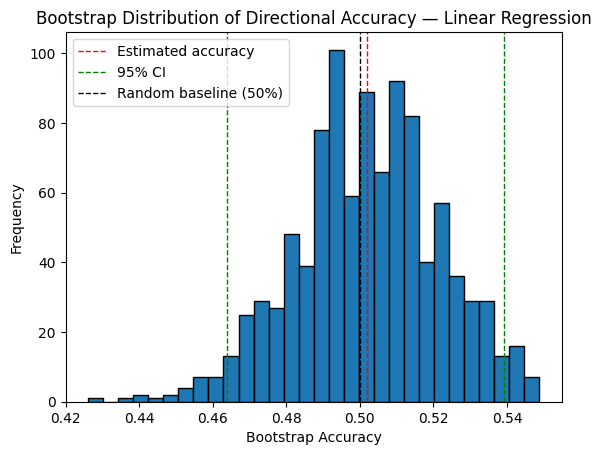

 
Logistic Regression
Estimated accuracy: 0.48839308176100626
Standard error:  0.0199486756064561
95% CI: [44.81%, 52.68%]


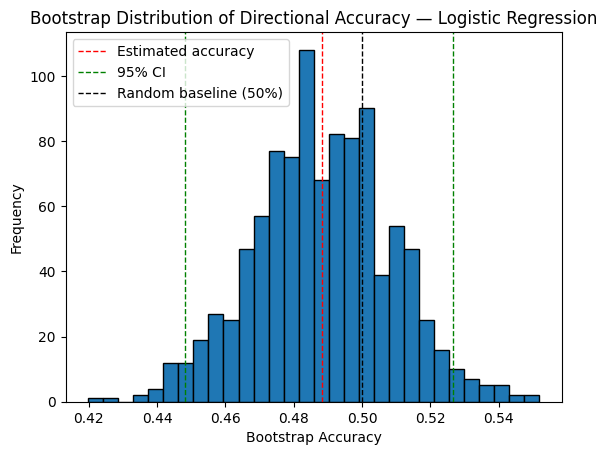

 
Lasso
Estimated accuracy: 0.5352169811320755
Standard error:  0.019713921427030365
95% CI: [49.69%, 57.23%]


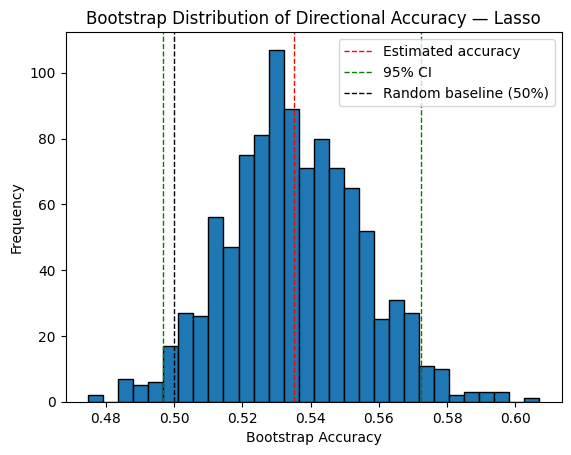

 
Random Forest
Estimated accuracy: 0.49912893081761006
Standard error:  0.020349373726411806
95% CI: [45.91%, 53.78%]


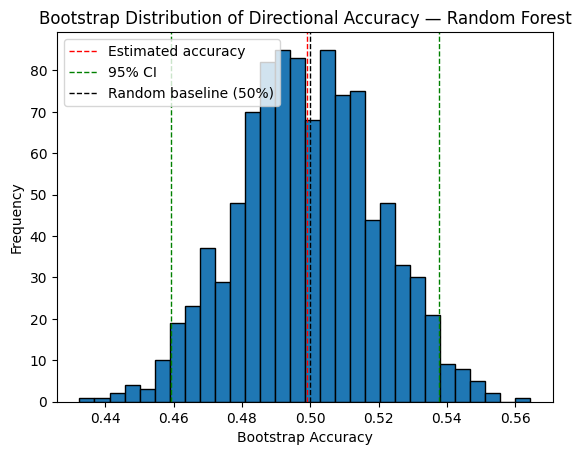

 
XGBoost
Estimated accuracy: 0.5392012578616352
Standard error:  0.019717422145735092
95% CI: [50.00%, 57.70%]


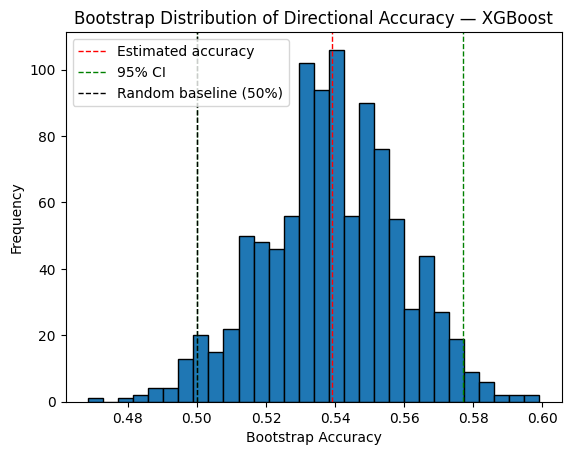

In [14]:
num_samples = 1000   # number of bootstrap resamples

actual_dir_bt = (y_test > 0).astype(int)

all_preds = {
    "Linear Regression":  (y_pred_lin   > 0).astype(int),
    "Logistic Regression": y_pred_log.astype(int),
    "Lasso":               (y_pred_lasso > 0).astype(int),
    "Random Forest":       (y_pred_rf    > 0).astype(int),
    "XGBoost":             (y_pred_xgb   > 0).astype(int),
}

ci_lower, ci_upper, ci_means = {}, {}, {}

for name, pred in all_preds.items():

    bootstrap_accs = np.zeros(num_samples)

    for i in range(num_samples):
        bootstrap_sample = np.random.choice(len(actual_dir_bt), size=len(actual_dir_bt), replace=True)
        bootstrap_acc    = accuracy_score(actual_dir_bt[bootstrap_sample], pred[bootstrap_sample])
        bootstrap_accs[i] = bootstrap_acc

    estimated_acc = np.mean(bootstrap_accs) # Estimated accuracy
    estimated_std = np.std(bootstrap_accs, ddof=1) # Estimated Standard Deviation
    confidence_interval = np.percentile(bootstrap_accs, [2.5, 97.5])

    ci_lower[name] = confidence_interval[0]
    ci_upper[name] = confidence_interval[1]
    ci_means[name] = estimated_acc

    print(" ")
    print(name)
    print("Estimated accuracy:", estimated_acc)
    print("Standard error: ", estimated_std)
    print(f"95% CI: [{confidence_interval[0]:.2%}, {confidence_interval[1]:.2%}]")

    # Histogram of bootstrap distribution — one per model
    plt.figure()
    plt.hist(bootstrap_accs, bins=30, edgecolor='black')
    plt.axvline(estimated_acc,           color='red',   linestyle='dashed', linewidth=1, label='Estimated accuracy')
    plt.axvline(confidence_interval[0],  color='green', linestyle='dashed', linewidth=1, label='95% CI')
    plt.axvline(confidence_interval[1],  color='green', linestyle='dashed', linewidth=1)
    plt.axvline(0.5,                     color='black', linestyle='dashed', linewidth=1, label='Random baseline (50%)')
    plt.xlabel('Bootstrap Accuracy')
    plt.ylabel('Frequency')
    plt.title(f'Bootstrap Distribution of Directional Accuracy — {name}')
    plt.legend()
    plt.show()



Price Prediction 3-day forward price

In [15]:
X_last = df_filtered[features].iloc[[-1]].values
X_last_lasso = df_filtered[lasso_features].iloc[[-1]].values
X_last_scaled = scaler.transform(X_last)
X_last_lasso_scaled = lasso_scaler.transform(X_last_lasso)

pred_lasso = lasso_model.predict(X_last_lasso_scaled)[0]
pred_rf = best_rf.predict(X_last)[0]
pred_xgb = best_xgb.predict(X_last)[0]

current_price = df_filtered["close"].iloc[-1]
ensemble = np.mean([pred_lasso, pred_rf, pred_xgb])

print("3-Day Forward Price Prediction")
print()
print(f"Current BTC price: ${current_price:,.2f}")
print(f"Lasso: {pred_lasso:+.4f} -> ${current_price * (1 + pred_lasso):,.2f}")
print(f"Random Forest: {pred_rf:+.4f} -> ${current_price * (1 + pred_rf):,.2f}")
print(f"XGBoost: {pred_xgb:+.4f} -> ${current_price * (1 + pred_xgb):,.2f}")
print(f"Average Direction: {'UP' if ensemble > 0 else 'DOWN'}")



3-Day Forward Price Prediction

Current BTC price: $71,214.62
Lasso: +0.0098 -> $71,910.20
Random Forest: -0.0041 -> $70,923.92
XGBoost: +0.0034 -> $71,453.27
Average Direction: UP


Plots


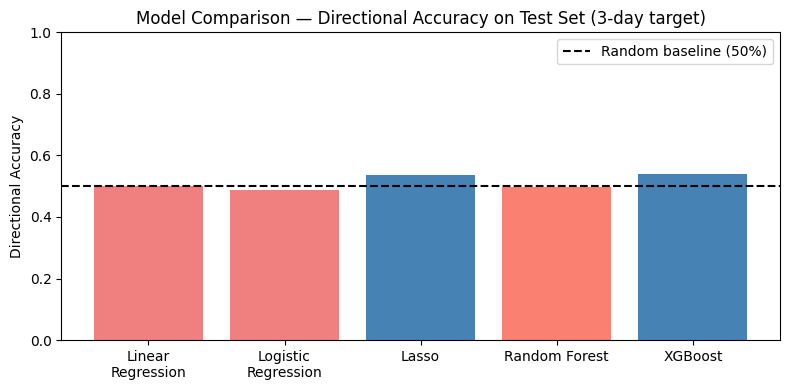

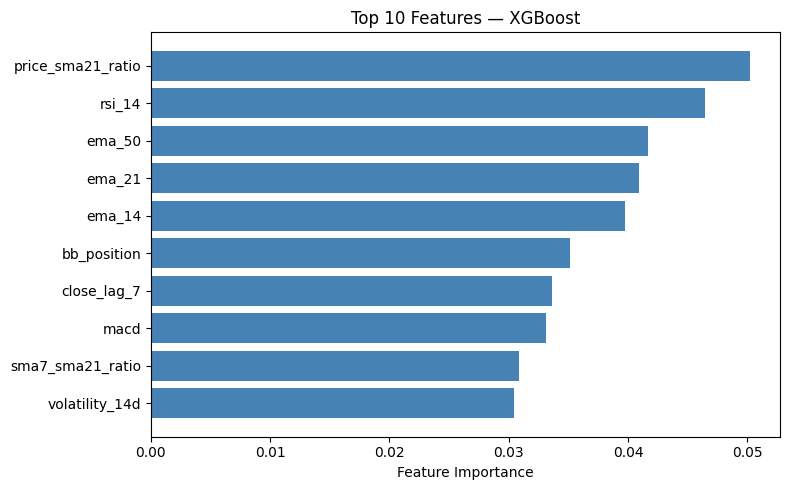

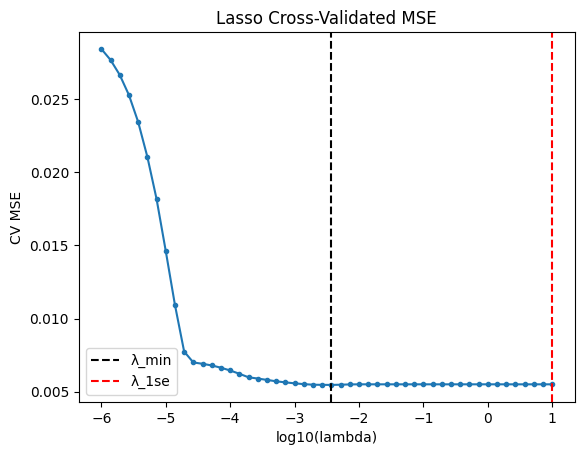

c:\Users\George Zavala\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.464e-02, tolerance: 1.313e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\George Zavala\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.024e-02, tolerance: 1.313e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\George Zavala\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the n

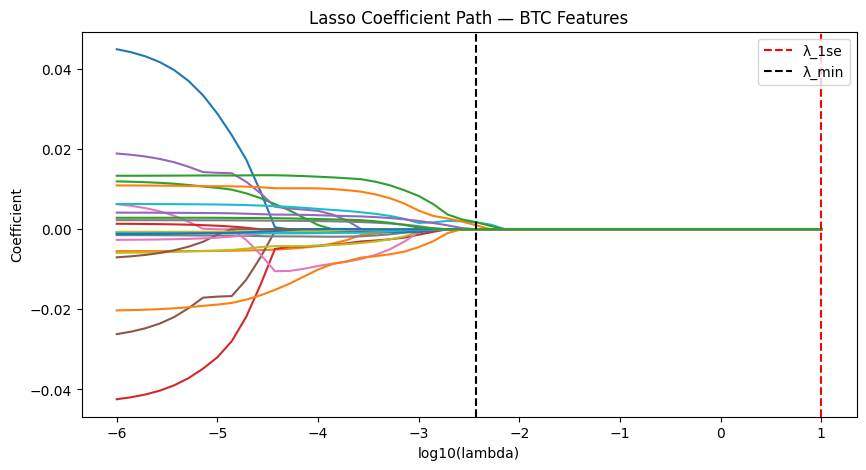

In [16]:
model_names = ["Linear\nRegression", "Logistic\nRegression", "Lasso", "Random Forest", "XGBoost"]
dir_accs    = [lin_dir_acc, log_dir_acc, dir_acc_lasso, dir_acc_rf, dir_acc_xgb]
colors      = ["lightcoral" if i < 2 else ("steelblue" if a > 0.5 else "salmon")
               for i, a in enumerate(dir_accs)]

plt.figure(figsize=(8, 4))
plt.bar(model_names, dir_accs, color=colors)
plt.axhline(0.5, color="black", linestyle="--", label="Random baseline (50%)")
plt.ylabel("Directional Accuracy")
plt.title("Model Comparison — Directional Accuracy on Test Set (3-day target)")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# XGBoost feature importance
xgb_importances = pd.Series(best_xgb.feature_importances_, index=features)
top10_xgb = xgb_importances.nlargest(10).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(top10_xgb.index, top10_xgb.values, color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Top 10 Features — XGBoost")
plt.tight_layout()
plt.show()

# Lasso CV loss curve
plt.figure()
plt.plot(np.log10(lambdas), cv_mse, marker="o", markersize=3)
plt.axvline(np.log10(lambda_min), color="black", linestyle="--", label="λ_min")
plt.axvline(np.log10(lambda_1se), color="red", linestyle="--", label="λ_1se")
plt.xlabel("log10(lambda)")
plt.ylabel("CV MSE")
plt.title("Lasso Cross-Validated MSE")
plt.legend()
plt.show()

# Lasso coefficient path
alphas_path, coefs_path, _ = lasso_path(
    X_lasso_train_scaled, y_train,
    alphas=np.logspace(-6, 1, 50)
)
plt.figure(figsize=(10, 5))
for i in range(coefs_path.shape[0]):
    plt.plot(np.log10(alphas_path), coefs_path[i])
plt.axvline(np.log10(lambda_1se), color="red", linestyle="--", label="λ_1se")
plt.axvline(np.log10(lambda_min), color="black", linestyle="--", label="λ_min")
plt.xlabel("log10(lambda)")
plt.ylabel("Coefficient")
plt.title("Lasso Coefficient Path — BTC Features")
plt.legend()
plt.show()